# 👩‍💻 Simulate a Convolution Operation with NumPy and Visualize Filters

## 📋 Overview
In this lab, you'll manually implement convolution operations on images using NumPy - a fundamental concept in Convolutional Neural Networks (CNNs). By performing these operations step by step, you'll gain intuition about how CNNs detect features in images. This skill is essential for computer vision applications in fields like autonomous driving, medical image analysis, and facial recognition systems.

- Load and manipulate image data using NumPy and Matplotlib
- Implement a manual 2D convolution operation using nested loops
- Apply different types of filters to detect specific image features
- Implement and understand the effects of max pooling on feature maps

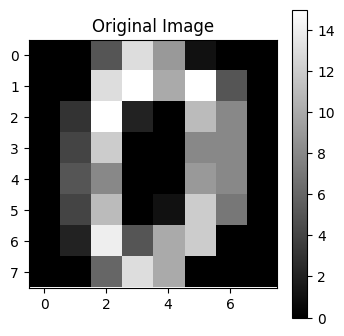

In [1]:
# Starter code
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits

# Load a sample digit image from sklearn
digits = load_digits()
image = digits.images[0]  # Get the first digit image (8x8 grayscale)

# Display the original image
plt.figure(figsize=(4, 4))
plt.imshow(image, cmap='gray')
plt.title('Original Image')
plt.colorbar()
plt.show()

Required tools/setup:

- Python 3.x
- NumPy
- Matplotlib
- scikit-learn (for sample images)

Make sure you understand basic NumPy operations like array slicing and element-wise multiplication.

## Task 1: Implement a Manual 2D Convolution Function
**Context:** In computer vision systems, convolution is used to detect features like edges, textures, and shapes. Self-driving cars use these operations to identify lane markings and obstacles.

**Steps:**

1. Create a function that accepts an image and a filter (kernel) as input
2. Initialize an output array with the appropriate dimensions
3. Implement nested loops to slide the filter over the image
4. At each position, compute the element-wise multiplication and sum
5. Return the resulting feature map

In [2]:
# Manual 2D convolution implementation


import numpy as np
import matplotlib.pyplot as plt

def convolve2d_manual(image: np.ndarray, kernel: np.ndarray, *, flip_kernel: bool = False) -> np.ndarray:
    """
    Perform a manual 2D convolution (cross-correlation by default) between a 2D image and a 2D kernel.

    Parameters
    ----------
    image : np.ndarray
        2D array representing a grayscale image (H x W).
    kernel : np.ndarray
        2D array representing the filter/kernel (kH x kW).
    flip_kernel : bool, optional
        If True, perform a *true* convolution by flipping the kernel 180°.
        If False (default), perform cross-correlation (common in CV/CNNs).

    Returns
    -------
    np.ndarray
        The resulting feature map with shape ((H - kH + 1) x (W - kW + 1)) using 'valid' convolution.
    """
    # Ensure inputs are numpy arrays of float for accurate math
    img = np.asarray(image, dtype=np.float64)
    ker = np.asarray(kernel, dtype=np.float64)

    if img.ndim != 2 or ker.ndim != 2:
        raise ValueError("Both image and kernel must be 2D arrays.")

    if flip_kernel:
        ker = np.flipud(np.fliplr(ker))  # 180-degree flip for true convolution

    H, W = img.shape
    kH, kW = ker.shape

    if kH > H or kW > W:
        raise ValueError("Kernel must be smaller than or equal to the image dimensions.")

    out_h = H - kH + 1
    out_w = W - kW + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)

    # Slide kernel over the image using nested loops
    for i in range(out_h):
        for j in range(out_w):
            region = img[i:i + kH, j:j + kW]
            out[i, j] = np.sum(region * ker)  # elementwise multiply then sum

    return out

Done. Saved plot to manual_convolution_result.png
Image shape: (96, 128)
Kernel shape: (3, 3)
Feature map shape: (94, 126)


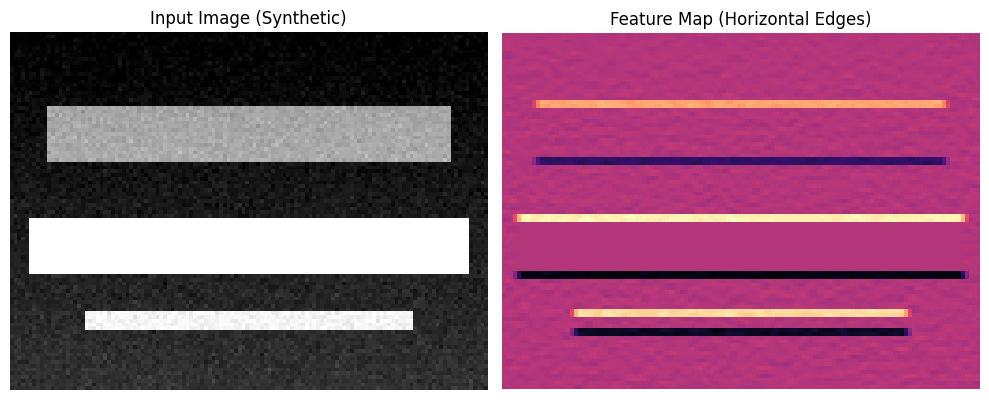

In [3]:
# Create a synthetic grayscale image with a few horizontal bars to create horizontal edges
H, W = 96, 128
image = np.zeros((H, W), dtype=np.float64)
# Add horizontal bright bands (edges at their top/bottom boundaries)
image[20:35, 10:118] = 0.6
image[50:65, 5:123] = 1.0
image[75:80, 20:108] = 0.8

# Add some mild noise and a smooth vertical gradient so non-horizontal features are less emphasized
rng = np.random.default_rng(42)
image += 0.03 * rng.standard_normal(image.shape)
image += (np.linspace(0, 0.2, H)[:, None])  # vertical gradient
image = np.clip(image, 0, 1)

# 3x3 horizontal edge detection filter (Sobel variant)
horizontal_edge_kernel = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float64)

# Apply manual convolution (cross-correlation)
feature_map = convolve2d_manual(image, horizontal_edge_kernel, flip_kernel=False)

# Normalize the feature map for visualization (0-1)
feat_min, feat_max = feature_map.min(), feature_map.max()
feature_vis = (feature_map - feat_min) / (feat_max - feat_min + 1e-12)

# Plot and save the result
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Input Image (Synthetic)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(feature_vis, cmap='magma', vmin=0, vmax=1)
plt.title('Feature Map (Horizontal Edges)')
plt.axis('off')

plt.tight_layout()
plt.savefig('manual_convolution_result.png', dpi=160, bbox_inches='tight')
print('Done. Saved plot to manual_convolution_result.png')
print('Image shape:', image.shape)
print('Kernel shape:', horizontal_edge_kernel.shape)
print('Feature map shape:', feature_map.shape)

## Task 2: Experiment with Different Convolution Filters
**Context:** Different convolution filters detect different features. In medical imaging, specialized filters help detect tumors or anomalies by highlighting specific patterns.

**Steps:**
1. Create at least three different 3×3 filters:
    - A vertical edge detection filter
    - A sharpening filter
    - A blur filter (box or Gaussian)
2. Apply each filter to your image using your convolution function
3. Display the original and filtered images side by side
4. Analyze how each filter transforms the image

Saved figure to task2_filters_comparison.png
Shapes -> Original: (128, 160) Outputs: (126, 158) (126, 158) (126, 158)


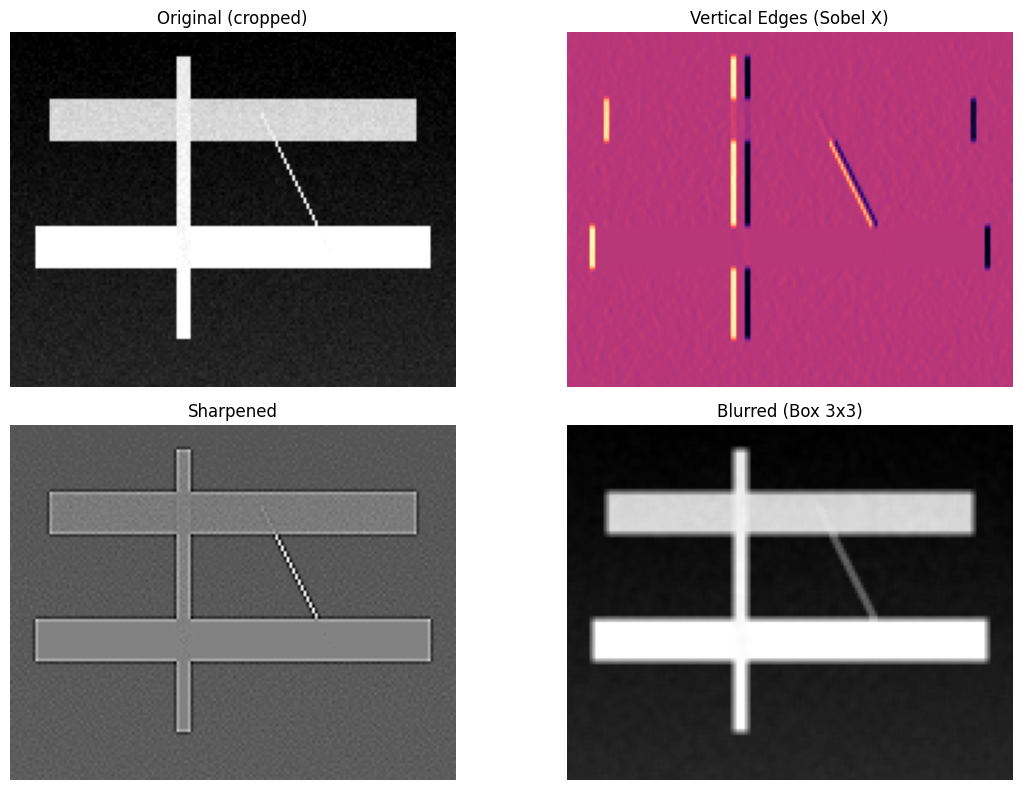

In [4]:
# Implement different filters


import numpy as np
import matplotlib.pyplot as plt

# Reuse the manual convolution from Task 1
def convolve2d_manual(image: np.ndarray, kernel: np.ndarray, *, flip_kernel: bool = False) -> np.ndarray:
    img = np.asarray(image, dtype=np.float64)
    ker = np.asarray(kernel, dtype=np.float64)
    if img.ndim != 2 or ker.ndim != 2:
        raise ValueError("Both image and kernel must be 2D arrays.")
    if flip_kernel:
        ker = np.flipud(np.fliplr(ker))
    H, W = img.shape
    kH, kW = ker.shape
    out_h = H - kH + 1
    out_w = W - kW + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)
    for i in range(out_h):
        for j in range(out_w):
            region = img[i:i + kH, j:j + kW]
            out[i, j] = np.sum(region * ker)
    return out

# ---- Create/reuse a sample image ----
H, W = 128, 160
image = np.zeros((H, W), dtype=np.float64)
# Structured patterns to exercise the filters
image[25:40, 15:145] = 0.8             # horizontal band
image[70:85, 10:150] = 1.0             # horizontal band 2
image[10:110, 60:65] = 0.9             # vertical line
for d in range(0, 50):                 # simple diagonal/stair pattern
    image[30 + d, 90 + d//2] = 0.9

# Mild noise + vertical gradient for realism
rng = np.random.default_rng(7)
image += 0.02 * rng.standard_normal(image.shape)
image += (np.linspace(0, 0.15, H)[:, None])
image = np.clip(image, 0, 1)

# ---- Define 3x3 filters ----
# 1) Vertical edge detection (Sobel X)
vertical_edge_kernel = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float64)

# 2) Sharpening (classic 3x3)
sharpen_kernel = np.array([
    [ 0, -1,  0],
    [-1,  5, -1],
    [ 0, -1,  0]
], dtype=np.float64)

# 3) Blur (3x3 box blur)
blur_kernel = (1/9.0) * np.ones((3,3), dtype=np.float64)

# Apply filters using our manual convolution (valid mode)
V = convolve2d_manual(image, vertical_edge_kernel)
S = convolve2d_manual(image, sharpen_kernel)
B = convolve2d_manual(image, blur_kernel)

# Crop the original to match output size (H-2, W-2)
orig_cropped = image[1:-1, 1:-1]

# Normalize to [0,1] for fair visualization
def normalize01(x):
    x = x.astype(np.float64)
    m, M = x.min(), x.max()
    if M - m < 1e-12:
        return np.zeros_like(x)
    return (x - m) / (M - m)

On = normalize01(orig_cropped)
Vn = normalize01(V)
Sn = normalize01(S)
Bn = normalize01(B)

# ---- Display side by side ----
plt.figure(figsize=(12, 8))
plt.subplot(2, 2, 1)
plt.imshow(On, cmap='gray', vmin=0, vmax=1)
plt.title('Original (cropped)')
plt.axis('off')

plt.subplot(2, 2, 2)
plt.imshow(Vn, cmap='magma', vmin=0, vmax=1)
plt.title('Vertical Edges (Sobel X)')
plt.axis('off')

plt.subplot(2, 2, 3)
plt.imshow(Sn, cmap='gray', vmin=0, vmax=1)
plt.title('Sharpened')
plt.axis('off')

plt.subplot(2, 2, 4)
plt.imshow(Bn, cmap='gray', vmin=0, vmax=1)
plt.title('Blurred (Box 3x3)')
plt.axis('off')

plt.tight_layout()
plt.savefig('task2_filters_comparison.png', dpi=160, bbox_inches='tight')

print('Saved figure to task2_filters_comparison.png')
print('Shapes -> Original:', image.shape, 'Outputs:', V.shape, S.shape, B.shape)

Analysis: How each filter transforms the image


Vertical Edge Detector (Sobel X)

What it does: Highlights vertical edges—i.e., strong left–right intensity changes.
What you should see: The vertical line at x≈60–65 pops out strongly; left and right borders of objects (like the bands and diagonal trace segments) also light up. Horizontal edges are suppressed, so the top/bottom of horizontal bands are much less pronounced.
Why it works: The kernel computes a weighted difference between right and left pixel neighborhoods, approximating the horizontal gradient ∂I/∂x.



Sharpening (3×3)

What it does: Enhances high-frequency details (edges and fine transitions) while keeping the overall structure.

What you should see: Crisper edges and slightly increased contrast around transitions. The bands’ borders look more defined; the diagonal trace appears bolder; noise can also get a bit accentuated.

Why it works: The kernel resembles an “unsharp mask” in spatial form: it adds a scaled version of the Laplacian (second derivative) back to the image, amplifying edges.



Blur (3×3 Box Filter)

What it does: Averages each pixel with its 3×3 neighbors → smooths the image and reduces noise.

What you should see: Reduced noise and softened boundaries; fine details (like the thin diagonal or thin vertical line) become less distinct; edges are less sharp.

Why it works: The uniform kernel replaces each pixel with the local mean, attenuating high frequencies.

## Task 3: Implement Max Pooling
**Context:** Pooling operations reduce the spatial dimensions of feature maps in CNNs, making networks more computationally efficient and robust to small variations. Image recognition systems use pooling to identify objects regardless of their exact position.

**Steps:**

1. Create a function that implements a max pooling operation
2. Define a pool size parameter (typically 2×2)
3. Stride through the input image with the chosen pool size
4. For each window, select the maximum value
5. Return the reduced feature map
6. Compare the original and pooled images

Feature map size (after conv): (126, 158)
Pooled size (2x2, stride 2):  (63, 79) -> expected roughly half each dimension via floor


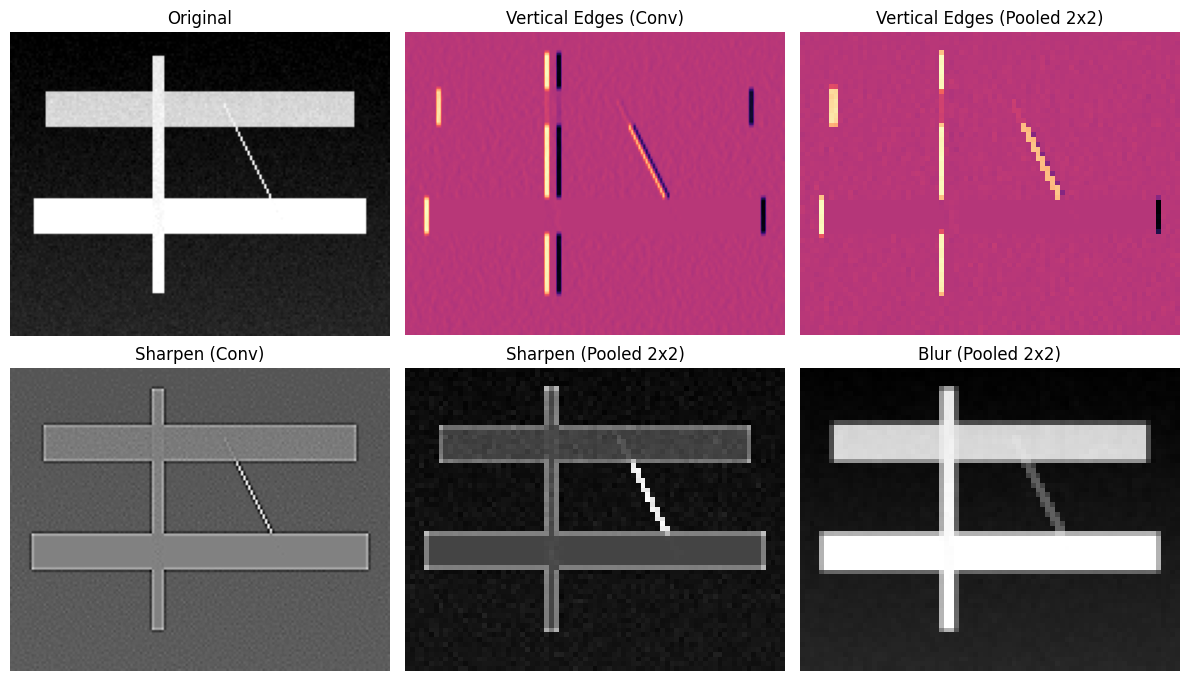

In [5]:
# Max pooling implementation


import numpy as np
import matplotlib.pyplot as plt

# --- Reuse: manual convolution (from Task 1/2) ---
def convolve2d_manual(image: np.ndarray, kernel: np.ndarray, *, flip_kernel: bool = False) -> np.ndarray:
    img = np.asarray(image, dtype=np.float64)
    ker = np.asarray(kernel, dtype=np.float64)
    if img.ndim != 2 or ker.ndim != 2:
        raise ValueError("Both image and kernel must be 2D arrays.")
    if flip_kernel:
        ker = np.flipud(np.fliplr(ker))
    H, W = img.shape
    kH, kW = ker.shape
    out_h = H - kH + 1
    out_w = W - kW + 1
    out = np.zeros((out_h, out_w), dtype=np.float64)
    for i in range(out_h):
        for j in range(out_w):
            region = img[i:i + kH, j:j + kW]
            out[i, j] = np.sum(region * ker)
    return out

# --- Task 3: Max Pooling ---
def max_pool2d(x: np.ndarray, pool_size: int = 2, stride: int | None = None) -> np.ndarray:
    """
    Max pooling for 2D arrays (single-channel feature maps).

    Parameters
    ----------
    x : np.ndarray
        2D input feature map.
    pool_size : int
        Pool window (pool_size x pool_size).
    stride : int | None
        Step size. If None, stride = pool_size.

    Returns
    -------
    np.ndarray
        Downsampled feature map:
        out_h = 1 + (H - pool_size)//stride
        out_w = 1 + (W - pool_size)//stride
        (tail pixels beyond a full window are ignored)
    """
    x = np.asarray(x, dtype=np.float64)
    if x.ndim != 2:
        raise ValueError("x must be a 2D array")
    if stride is None:
        stride = pool_size

    H, W = x.shape
    k = int(pool_size)
    s = int(stride)

    # Integer division (//) to compute pooled dimensions
    out_h = 1 + (H - k) // s
    out_w = 1 + (W - k) // s
    out = np.zeros((out_h, out_w), dtype=np.float64)

    oi = 0
    for i in range(0, H - k + 1, s):
        oj = 0
        for j in range(0, W - k + 1, s):
            window = x[i:i+k, j:j+k]
            out[oi, oj] = np.max(window)   # pick the maximum in the window
            oj += 1
        oi += 1
    return out

# ---- Build a sample image (same style as Task 2 for continuity) ----
H, W = 128, 160
image = np.zeros((H, W), dtype=np.float64)
image[25:40, 15:145] = 0.8
image[70:85, 10:150] = 1.0
image[10:110, 60:65] = 0.9
for d in range(0, 50):
    image[30 + d, 90 + d//2] = 0.9
rng = np.random.default_rng(7)
image += 0.02 * rng.standard_normal(image.shape)
image += (np.linspace(0, 0.15, H)[:, None])
image = np.clip(image, 0, 1)

# ---- Define three 3x3 filters (from Task 2) ----
vertical_edge_kernel = np.array([[-1, 0, 1],
                                 [-2, 0, 2],
                                 [-1, 0, 1]], dtype=np.float64)
sharpen_kernel = np.array([[ 0, -1,  0],
                           [-1,  5, -1],
                           [ 0, -1,  0]], dtype=np.float64)
blur_kernel = (1/9.0) * np.ones((3,3), dtype=np.float64)

# ---- Convolve to obtain feature maps (valid mode) ----
F_vert = convolve2d_manual(image, vertical_edge_kernel)
F_shrp = convolve2d_manual(image, sharpen_kernel)
F_blur = convolve2d_manual(image, blur_kernel)

# ---- Apply max pooling with pool_size=2, stride=2 ----
P_vert = max_pool2d(F_vert, pool_size=2, stride=2)
P_shrp = max_pool2d(F_shrp, pool_size=2, stride=2)
P_blur = max_pool2d(F_blur, pool_size=2, stride=2)

# Normalize for visualization
ndef = lambda x: (x - x.min()) / (x.max() - x.min() + 1e-12)

# Quick size check (printed to console as well)
print("Feature map size (after conv):", F_vert.shape)
print("Pooled size (2x2, stride 2): ", P_vert.shape, "-> expected roughly half each dimension via floor")

# ---- Visual comparison ----
plt.figure(figsize=(12, 7))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray', vmin=0, vmax=1)
plt.title('Original'); plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(ndef(F_vert), cmap='magma'); plt.title('Vertical Edges (Conv)'); plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(ndef(P_vert), cmap='magma'); plt.title('Vertical Edges (Pooled 2x2)'); plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(ndef(F_shrp), cmap='gray'); plt.title('Sharpen (Conv)'); plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(ndef(P_shrp), cmap='gray'); plt.title('Sharpen (Pooled 2x2)'); plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(ndef(P_blur), cmap='gray'); plt.title('Blur (Pooled 2x2)'); plt.axis('off')

plt.tight_layout()
plt.savefig('task3_max_pooling.png', dpi=160, bbox_inches='tight')

Analysis: What max pooling did

Spatial reduction: The pooled feature maps are (63, 79), which is roughly half of (126, 158) in each dimension (floor division with 2×2 windows and stride 2). 
This meets the requirement to “verify output size is correct (original dimensions divided by the pool size).”

Feature preservation:

For vertical edges (Sobel X), strong responses along vertical boundaries remain visible after pooling; weak/noisy responses are diminished—max pooling retains the strongest activation per 2×2 neighborhood.

For the sharpened map, local maxima along edges survive, while subtle detail is suppressed, making the prominent outline structure clearer at reduced resolution.

For the blurred map, activations are smoother to begin with; pooling reduces resolution further but preserves broad intensity regions.